# 통계 분석 함수

- 최대,최소,평균
- 중앙값: 데이터를 크기 순으로 정렬 했을 때, 가장 한가운데 위치한 값
- 최빈값: 데이터에서 가장 자주 등장하는 값
- 왜도: 정규분포선에서 데이터의 비대칭성을 나타내는 수치값
- 첨도: 정규분포선에서 데이터의 뾰족함을 나타내는 수치값
- 분산: 데이터의 퍼짐 정도(평균에 비해 얼마나 떨어져 있는지)에 대한 수치값
- 표준편차: 분산의 제곱근(실제 데이터의 스케일로 변환)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# scipy.stats: 파이썬을 활용한 통계분석의 전반적인 기능을 제공하는 패키지
from scipy import stats

In [2]:
np.random.seed(7)

# 일반 유저 데이터 생성(190명)
# normal: 정규분포를 이루는 데이터 생성
normal_users = np.random.normal(500000, 100000, 190) # (평균, 표준편차, 개수)

# VVIP 헤비 유저(10명)
vvip_users = np.random.normal(1000000, 300000, 10)

# 두 그룹 데이터를 순서대로 하나로 합침
raw_data = np.concatenate([normal_users, vvip_users])

# -2는 십의 자리에서 반올림 한다는 뜻(0.0을 기준으로 소수점이면 +1,+2,+3... 이고 정수면 -1,-2,-3 인식!)
data = np.round(raw_data, -2).astype(int)

In [3]:
data

array([ 669100,  453400,  503300,  540800,  421100,  500200,  499900,
        324500,  601800,  560000,  437500,  482800,  550500,  473900,
        475700,  354700,  555500,  512400,  527400,  347300,  665100,
        515400,  461300,  702900,  495500,  354900,  459500,  271200,
        604900,  458400,  425700,  607200,  334900,  553500,  293600,
        433800,  379600,  646200,  676600,  467100,  584100,  482000,
        556800,  424700,  329200,  319700,  538300,  724800,  526900,
        447500,  691200,  523700,  510100,  525300,  486800,  469100,
        356500,  550200,  490500,  619300,  463100,  309400,  490000,
        670000,  461700,  411000,  380600,  395000,  470000,  382000,
        649800,  471700,  510900,  643800,  650300,  478700,  533200,
        573500,  480700,  322200,  565500,  589400,  541600,  407600,
        480400,  440900,  470000,  629700,  653000,  566900,  554900,
        567700,  498800,  492400,  432600,  494400,  726000,  586900,
        465800,  452

## 2. 대푯값 확인

In [4]:
min_val = np.min(data)
max_val = np.max(data)
mean_val = np.mean(data)
median_val = np.median(data)


# : 는 출력형식을 지정하는 시작 신호
# , 는 천단위마다 콤마 찍기
# .0 은 소수점 0번째 자리에서 반올림(소수점 버리기)
# f는 실수 형태로 출력
print(f"최솟값(MIN): {min_val:,.0f}")
print(f"최댓값(MAX): {max_val:,.0f}")
print(f"평균값(MEAN): {mean_val:,.0f}")
print(f"중앙값(MEDIAN): {median_val:,.0f}")

최솟값(MIN): 271,200
최댓값(MAX): 1,619,100
평균값(MEAN): 521,826
중앙값(MEDIAN): 500,050


In [5]:
# mode: 최빈값(가장 자주 나온 값)과 그 빈도수
mode_val = stats.mode(data)
mode_val

ModeResult(mode=np.int64(470000), count=np.int64(2))

In [6]:
print(f"최빈값(Mode): {mode_val[0]:.0f}원 (빈도: {mode_val[1]}회)")

최빈값(Mode): 470000원 (빈도: 2회)


In [7]:
# skew: 왜도(데이터의 비대칭성)
skew_val = stats.skew(data)

# kurtosis: 첨도(데이터의 뾰족한 정도)
kurt_val = stats.kurtosis(data)

# 양의 왜도: 오른쪽 꼬리가 길고 소수의 극단값이 평균을 끌어올리고 있다는 뜻
# 음의 왜도: 왼쪽 꼬리가 길고 대부분이 평범한 충성 데이터들인데 일부 극단값(체리피커,이탈자 등)이 있을 수 있음
# 0인 경우: 정규분포 형태로 데이터들이 평범하고 예측가능한 패턴을 보인다는 뜻
# 절대값이 0.5 이하이면 거의 대칭인 정규분포라고 가정
# 절대값이 0.5~1.0 사이면 약간 치우쳐졌다고 보고 중앙값을 함께 체크
# 절대값이 1.0을 초과하면 심하게 치우쳐서 중앙값만 보거나 로그 변환 후 분석 필요
print(f"외도(Skewness): {skew_val:.2f}")


# kurosis함수의 출력 결과가 0이라는 것은 첨도가 3(정규분포)이라는 뜻
# 따라서 - 가 나오면 저첨도(정규분포보다 평평함), + 가나오면 고첨도(정규분포보다 뾰족함)가 됨
# 고첨도이면 평균 주변에 데이터가 주로 분포해서 안정적인 예측이 가능하지만 이상치 리스크도 있음
# 저첨도이면 데이터가 전체적으로 골고루 퍼져있어 데이터의 패턴이 제각각이란 의미로 타겟을 더 세분화 해야함
print(f"첨도(kurtosis): {kurt_val:.2f}")

외도(Skewness): 3.04
첨도(kurtosis): 14.22


In [8]:
# 분산
var_val = np.var(data)

# 표준편차
std_val = np.std(data)


print(f"분산(Variance): {var_val:,.0f}")
print(f"표준편차(Standard):{std_val:,.0f}")

분산(Variance): 27,629,812,548
표준편차(Standard):166,222


### 3. 이상치 탐지 및 성과 확인을 위한 Z-score 활용
- 우리의 데이터가 정규분포 형태로 만들어졌기  때문에 Z-score 활용 가능
- 모든 데이터가 평균에서 몇 시그마 만큼 떨어져 있는지 수치로 확인

In [9]:
z_score = stats.zscore(data)
np.round(z_score, 2)

# 우리 데이터는 200명의 구매금액 데이터이므로 (-)라면 평균보다 금액이 낮고
# (+)라면 평균보다 금액이 높으며, +2라면 표준편차(약 32만원) 만큼 크다는 의미

array([ 0.89, -0.41, -0.11,  0.11, -0.61, -0.13, -0.13, -1.19,  0.48,
        0.23, -0.51, -0.23,  0.17, -0.29, -0.28, -1.01,  0.2 , -0.06,
        0.03, -1.05,  0.86, -0.04, -0.36,  1.09, -0.16, -1.  , -0.37,
       -1.51,  0.5 , -0.38, -0.58,  0.51, -1.12,  0.19, -1.37, -0.53,
       -0.86,  0.75,  0.93, -0.33,  0.37, -0.24,  0.21, -0.58, -1.16,
       -1.22,  0.1 ,  1.22,  0.03, -0.45,  1.02,  0.01, -0.07,  0.02,
       -0.21, -0.32, -0.99,  0.17, -0.19,  0.59, -0.35, -1.28, -0.19,
        0.89, -0.36, -0.67, -0.85, -0.76, -0.31, -0.84,  0.77, -0.3 ,
       -0.07,  0.73,  0.77, -0.26,  0.07,  0.31, -0.25, -1.2 ,  0.26,
        0.41,  0.12, -0.69, -0.25, -0.49, -0.31,  0.65,  0.79,  0.27,
        0.2 ,  0.28, -0.14, -0.18, -0.54, -0.16,  1.23,  0.39, -0.34,
       -0.42, -0.65,  0.09,  0.1 , -1.  ,  0.16, -0.47,  0.73, -0.04,
        0.9 , -0.41, -0.3 ,  0.05,  0.5 ,  0.21, -0.87, -0.02, -0.12,
       -0.39, -0.52,  0.92, -0.37, -0.64,  0.25, -0.05, -0.18,  0.34,
        0.16,  0.09,

In [10]:
df_revenue = pd.DataFrame({"일일 매출액": data,
                          "Z-Score": np.round(z_score, 2)},
                         index = range(1, len(data)+1))
df_revenue

,일일 매출액,Z-Score
1,669100,0.89
2,453400,-0.41
3,503300,-0.11
4,540800,0.11
5,421100,-0.61
...,...,...
196,1619100,6.60
197,426800,-0.57
198,1190900,4.03
199,1281700,4.57


In [11]:
# Z-Score의 절대값이 2.0 이상인 데이터(정규분포 95% 바깥임으로 이상치로 가정)만 필터링 해보세요

In [12]:
# 불리언 인덱싱: 데이터 프레임명[집계함수(데이터프레임['컬럼명']) 비교 연산자]
outliers = df_revenue[abs(df_revenue['Z-Score'])>=2.0]
print(outliers)

      일일 매출액  Z-Score
191  1082000     3.37
193  1324700     4.83
196  1619100     6.60
198  1190900     4.03
199  1281700     4.57
200  1044100     3.14


In [13]:
print("="*60)
print("[Z-Score 활용] 비정상 매출 발생 탐지 리포트")
print("="*60)
print(f"총 200명 중 일반적인 금액을 크게 벗어난(Z >= 2 또는 Z <= -2 데이터는 총 {len(outliers)}명!!")

#금액이 가장 높았던 Top 3
print("[Best 퍼포먼스 Top 3]")
print(df_revenue.sort_values(by="Z-Score", ascending = False).head(3))
print("-"*60)

#금액이 가장 낮았던 Worst 3
print("[Worst 퍼포먼스 Top 3]")
print(df_revenue.sort_values(by='Z-Score', ascending = True).head(3))
print("-"*60)

[Z-Score 활용] 비정상 매출 발생 탐지 리포트
총 200명 중 일반적인 금액을 크게 벗어난(Z >= 2 또는 Z <= -2 데이터는 총 6명!!
[Best 퍼포먼스 Top 3]
      일일 매출액  Z-Score
196  1619100     6.60
193  1324700     4.83
199  1281700     4.57
------------------------------------------------------------
[Worst 퍼포먼스 Top 3]
     일일 매출액  Z-Score
28   271200    -1.51
35   293600    -1.37
139  304800    -1.31
------------------------------------------------------------


In [14]:
# 한 번에 여러 기술 통계량 확인 하기
stats.describe(data)

# nobs: 데이터의 개수
# minmax: 최대최소값
# meab: 평균
# variance: 분산
# skewness: 왜도
# urtosis: 첨도

DescribeResult(nobs=np.int64(200), minmax=(np.int64(271200), np.int64(1619100)), mean=np.float64(521826.5), variance=np.float64(27768655826.88442), skewness=np.float64(3.0359587350371653), kurtosis=np.float64(14.221952472369257))

In [15]:
# 내부 특정 값에 접근하기
stats.describe(data).minmax

(np.int64(271200), np.int64(1619100))

### 4. 시각화: 히스토그램(+정규분포 곡선) & 박스플롯

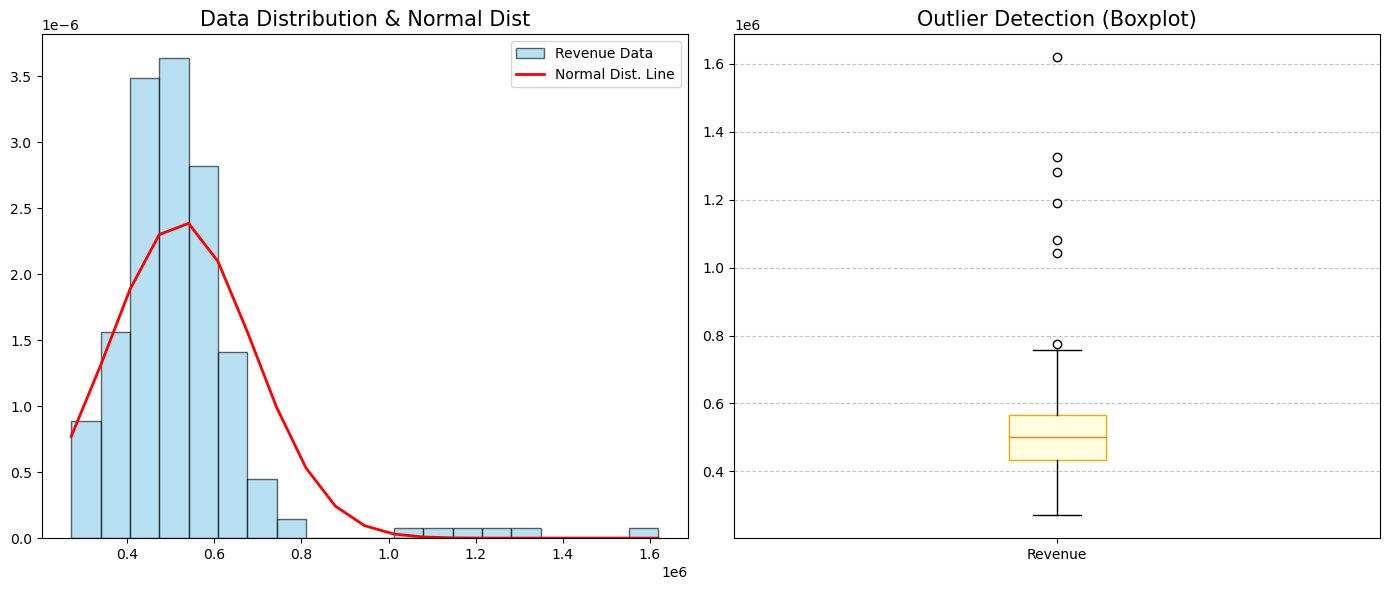

In [30]:
plt.figure(figsize=(14,6))

# 1행2열 중 1번째(좌측) 서브플롯에 히스토그램 & 정규분포 곡선 그리기
plt.subplot(1,2,1)

# hist: 히스토그램(구간별 데이터의 개수를 출력) 생성 함수
# count: 각 막대의 높이(=구간별 데이터의 개수)
# bins_value: 막대의 x축의 경계선의 수치값
# _ : 3가자의 정보를 받아야하는데 _로 3번째 정보는 받지 않는다고 표시
count, bins_value, _ = plt.hist(
    data,                   # 데이터
    bins = 20,              # 구간 개수
    color = "skyblue",      # 막대 색상
    edgecolor = "black",    # 막대 겉 테두리 색상
    alpha = 0.6,            # 투명도
    label = "Revenue Data", # 명칭
    density = True          # 각 막대의 면적을 전체 데이터에서 차지하는 비율로 변경(전체 면적의 합이 1이 되도록!)
                            # (아래 pdf함수는 전체 면적이 1이 되었을 때 그려지도록 설계가 되어 있음)
)

# 확인용
# print("count : \n", count)
# print("bins_value : \n", bins_value)

# 정규분포 곡선 그리기
plt.plot(
    bins_value,
    # norm.pdf: 정규분포 선 그리는 함수(pdf는 Probability Density Function으로 확률밀도 함수라는 뜻)
    #           (pdf를 사용하면 x축 위치에서 선이 찍힐 y축의 높이를 자동으로 계산해줌)
    stats.norm.pdf(bins_value, mean_val, std_val),  # (x축 구간, 편균, 표준편차)
    linewidth = 2,
    color = "red",
    label = "Normal Dist. Line"
)

plt.title("Data Distribution & Normal Dist", fontsize = 15)
plt.legend()

# 1행2열 중 2번째(우측) 서브플롯에 박스플롯 그리기
plt.subplot(1,2,2)

plt.boxplot(
    data,
    vert = True,         # 상자를 수직(세로)으로 출력  
    patch_artist = True, # 상자 내부 꾸미기 on/off(True여야 boxprops설정이 가능)
    # facecolor: 상자 내부 면적 색상
    # color: 상자 바깥쪽 테두리 색상
    boxprops = dict(facecolor = "lightyellow", color = "orange")
)

plt.title("Outlier Detection (Boxplot)", fontsize = 15)
plt.xticks([1], ["Revenue"])
# axis = "y": 격자선은 y축만
plt.grid(axis="y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()

### 5. 이상치 처리 전략

### 1) 이상치 제거(Trimming)

In [17]:
df_revenue

,일일 매출액,Z-Score
1,669100,0.89
2,453400,-0.41
3,503300,-0.11
4,540800,0.11
5,421100,-0.61
...,...,...
196,1619100,6.60
197,426800,-0.57
198,1190900,4.03
199,1281700,4.57


▶1. 이상치 제거 후 데이터 개수: 194 개 (6명 제외됨)
 - 제거 전 평균: 521,826원 -> 제거 후 평균: 499,087원
 - 제거 전 왜도: 3.04 -> 제거 후 왜도: 0.15
 - 제거 전 첨도: 14.22 -> 제거 후 첨도: -0.28


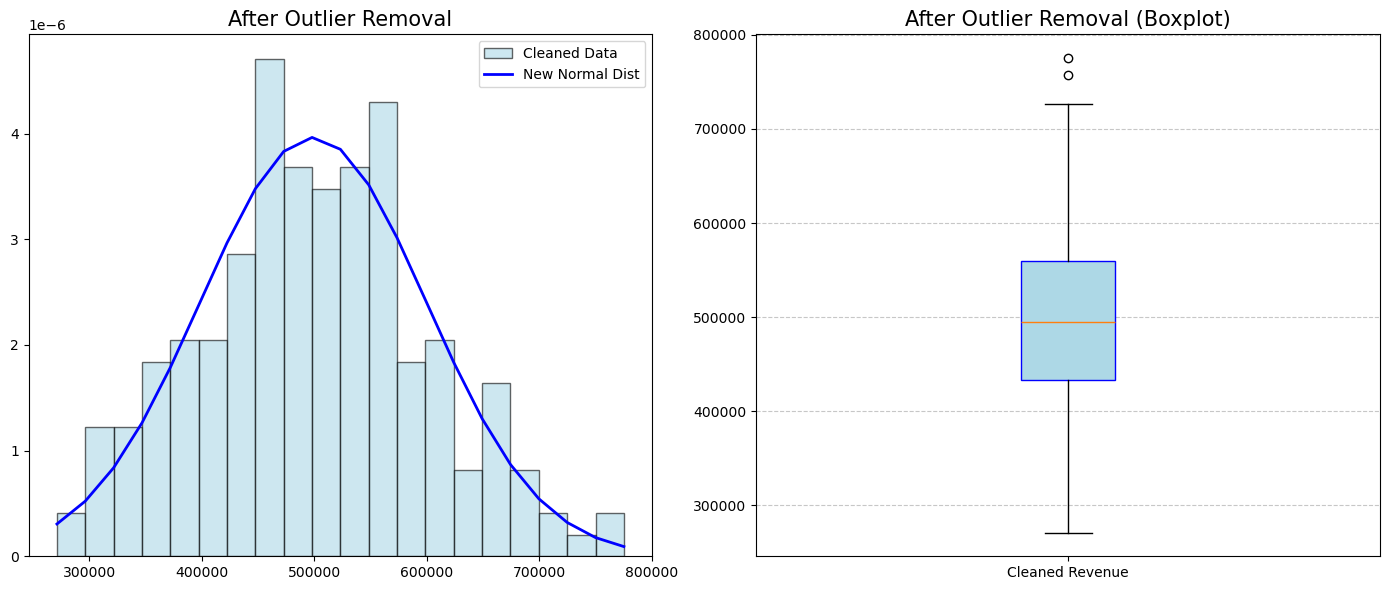

In [29]:
# 이상치를 뺀 나머지 데이터(Z-score의 절대값이 2 미만인!)
clean_data = df_revenue[abs(df_revenue['Z-Score']) < 2.0]["일일 매출액"]

print(f"▶1. 이상치 제거 후 데이터 개수: {len(clean_data)} 개 ({len(data)-len(clean_data)}명 제외됨)")
print(f" - 제거 전 평균: {mean_val:,.0f}원 -> 제거 후 평균: {np.mean(clean_data):,.0f}원")
print(f" - 제거 전 왜도: {skew_val:,.2f} -> 제거 후 왜도: {stats.skew(clean_data):,.2f}")
print(f" - 제거 전 첨도: {kurt_val:,.2f} -> 제거 후 첨도: {stats.kurtosis(clean_data):,.2f}")


# 이상치 제거 후의 새로운 평균, 표준편차
clean_mean = np.mean(clean_data)
clean_std = np.std(clean_data)



# 이상치 처리 후 시각화
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
count_cl, bins_cl, _ = plt.hist(
    clean_data,                  
    bins = 20,             
    color = "lightblue",      
    edgecolor = "black",    
    alpha = 0.6,            
    label = "Cleaned Data", 
    density = True          
                            
)

plt.plot(
    bins_cl,
    stats.norm.pdf(bins_cl, clean_mean, clean_std),  
    linewidth = 2,
    color = "blue",
    label = "New Normal Dist"
)

plt.title("After Outlier Removal", fontsize = 15)
plt.legend()




plt.subplot(1,2,2)

plt.boxplot(
    clean_data,
    vert = True,         
    patch_artist = True, 
    
    boxprops = dict(facecolor = "lightblue", color = "blue")
)

plt.title("After Outlier Removal (Boxplot)", fontsize = 15)
plt.xticks([1], ["Cleaned Revenue"])
plt.grid(axis="y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()

### 2) 로그 변환
- 데이터를 버릴 수 없을 때, 로그를 씌워 정규분포 형태로 다듬기

▶ 2. 로그 변환(데이터를 버리지 않고 분석하기 편하게 형태만 바꾸기)
 - 변환 전 왜도: 3.04 -> 변환 후 왜도: 0.98
 - 변환 전 첨도: 14.22 -> 변환 후 첨도: 3.32


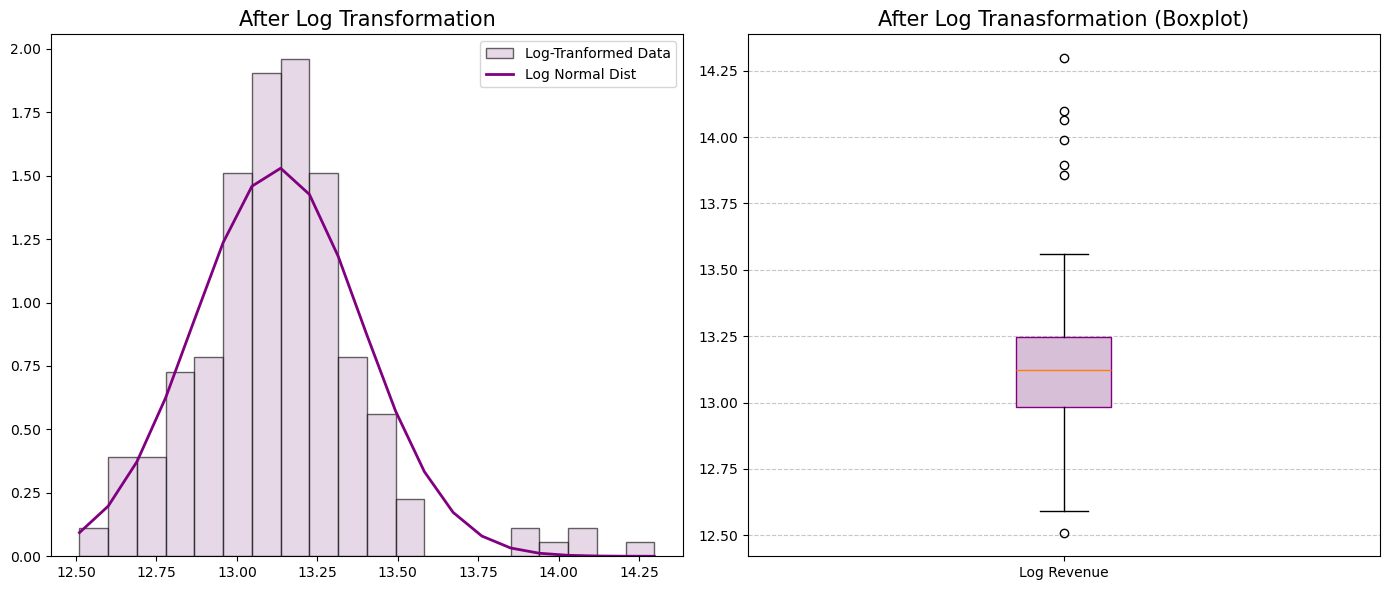

In [28]:
# log1p: 데이터에 0이 있을 경우 에러가 나는것을 방지하는 안전한 로그 함수
log_data = np.log1p(data)

# 로그 변환 전후의 왜도, 첨도 비교
print(f"▶ 2. 로그 변환(데이터를 버리지 않고 분석하기 편하게 형태만 바꾸기)")
print(f" - 변환 전 왜도: {skew_val:,.2f} -> 변환 후 왜도: {stats.skew(log_data):,.2f}")
print(f" - 변환 전 첨도: {kurt_val:,.2f} -> 변환 후 첨도: {stats.kurtosis(log_data):,.2f}")

# 로그 변환 후 새로운 평균, 표준편차
log_mean = np.mean(log_data)
log_std = np.std(log_data)

# 이상치 처리(로그 변환) 후 시각화
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
count_lo, bins_lo, _ = plt.hist(
    log_data,                  
    bins = 20,             
    color = "thistle",      
    edgecolor = "black",    
    alpha = 0.6,            
    label = "Log-Tranformed Data", 
    density = True          
                            
)

plt.plot(
    bins_lo,
    stats.norm.pdf(bins_lo, log_mean, log_std),  
    linewidth = 2,
    color = "purple",
    label = "Log Normal Dist"
)

plt.title("After Log Transformation", fontsize = 15)
plt.legend()




plt.subplot(1,2,2)

plt.boxplot(
    log_data,
    vert = True,         
    patch_artist = True, 
    
    boxprops = dict(facecolor = "thistle", color = "purple")
)

plt.title("After Log Tranasformation (Boxplot)", fontsize = 15)
plt.xticks([1], ["Log Revenue"])
plt.grid(axis="y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()

### 3) 윈저라이징
- 극단값을 버리지 않고, 상한선(혹은 하한선)으로 대체해서 보존하는 방법

▶ 3. 윈저라이징
 - 상위 5% 커트라인 금액: 703,995원
 - 변환전 최댓값: 1,619,100원 -> 변환후 최대값: 703,995원
 - 실제 총 금액: 104,365,300원 -> 변환후 총 금액: 100,878,850원
  => 3,486,450원의 결제금액이 축소 보고됨


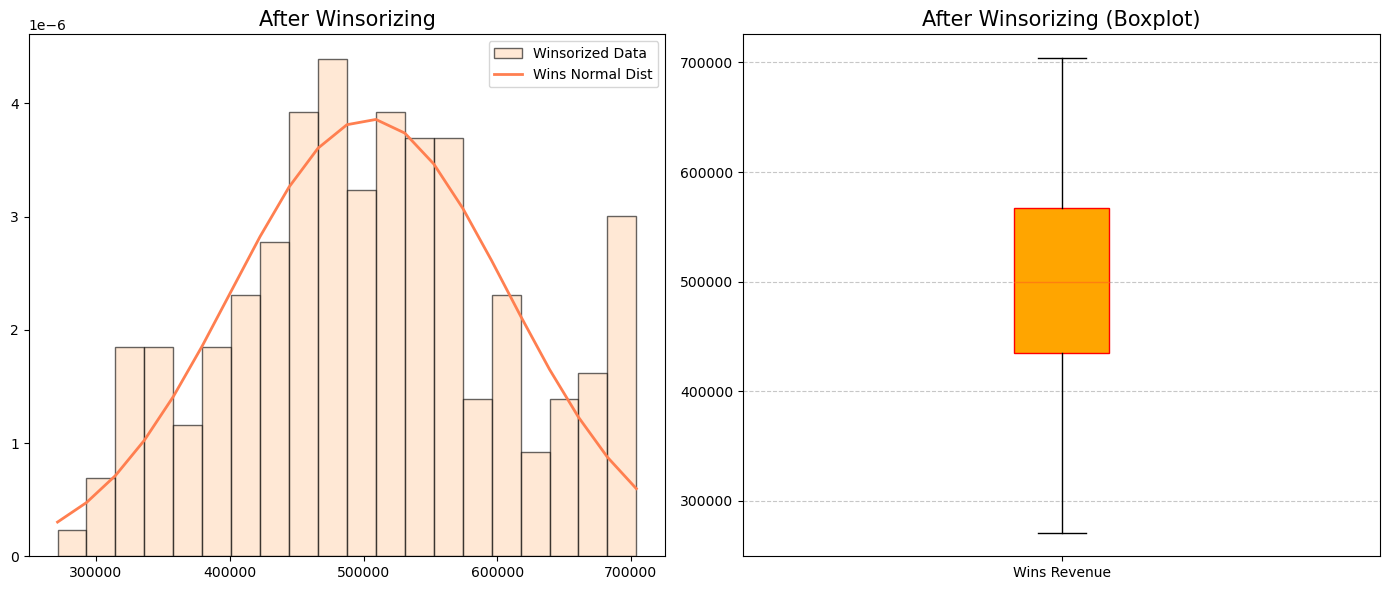

In [33]:
print("▶ 3. 윈저라이징")

# 상위 5% 위치의 결제 금액(상한선)이 얼마인지 계산
upper_cap = np.percentile(data,95)   # 전체 데이터에서 95% 부분에 위치한 값

print(f" - 상위 5% 커트라인 금액: {upper_cap:,.0f}원")

# np.clip: 사용자가 지정한 하한선과 상한선 범위에 벗어나는 값을 임계값으로 제한
# a_min: 하한선 임계값
# a_max: 상한선 임계값
winsorized_data = np.clip(data, a_min = None, a_max=upper_cap)

print(f" - 변환전 최댓값: {np.max(data):,.0f}원 -> 변환후 최대값: {np.max(winsorized_data):,.0f}원")

# 윈저라이징으로 왜곡되는 총 금액 출력
print(f" - 실제 총 금액: {np.sum(data):,.0f}원 -> 변환후 총 금액: {np.sum(winsorized_data):,.0f}원")
print(f"  => {np.sum(data) - np.sum(winsorized_data):,.0f}원의 결제금액이 축소 보고됨")

# 윈저라이징 후 평균과 표준편차
win_mean = np.mean(winsorized_data)
win_std = np.std(winsorized_data)


plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
count_win, bins_win, _ = plt.hist(
    winsorized_data,                  
    bins = 20,             
    color = "peachpuff",      
    edgecolor = "black",    
    alpha = 0.6,            
    label = "Winsorized Data", 
    density = True          
                            
)

plt.plot(
    bins_win,
    stats.norm.pdf(bins_win, win_mean, win_std),  
    linewidth = 2,
    color = "coral",
    label = "Wins Normal Dist"
)

plt.title("After Winsorizing", fontsize = 15)
plt.legend()




plt.subplot(1,2,2)

plt.boxplot(
    winsorized_data,
    vert = True,         
    patch_artist = True, 
    
    boxprops = dict(facecolor = "orange", color = "red")
)

plt.title("After Winsorizing (Boxplot)", fontsize = 15)
plt.xticks([1], ["Wins Revenue"])
plt.grid(axis="y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()

#### 결과
- 상위 5% 이내의 데이터가 한 구간으로 합쳐지며 히스토그램의 마지막 구 빈도수가 많아짐

#### 윈저라이징 효과적인 경우
1) 극단값이 시스템 오류나 크롤러와 가은 봇(bot) 데이터인게 확실시 될 때
2) 정규분포곡선의 우측이나 좌측 꼬리가 극단적으로 긴 데이터를 모두 활용해야 할 때
3) 머신러닝 예측 성능을 안정화시키기 위해 극단값을 줄여줘야할 때

#### 윈저라이징 역효과가 나는 경우
1) 극단값 자체가 비즈니스의 핵심 타겟 일 때 ex) VVIP마케팅. 신용카드 사기탐지, 공장불량률 탐지 등
2) 총합이나 재무적 지표를 정확하게 계산해야 할 때

### 4) 타겟 분리
- 이상치를 버리지 않고 '특별 관리 그룹' 으로 떼어내어 활용(마케팅에서 주로 활용)

▶ 4. 분리 (일반 고객 vs VVIP 고객 투트랙 분석)
 [일반 타겟 그룹]194명 / 평균 결제일: 499,087원
 [VVIP 타겟 그룹]6명 / 평균 결제일: 1,257,083원


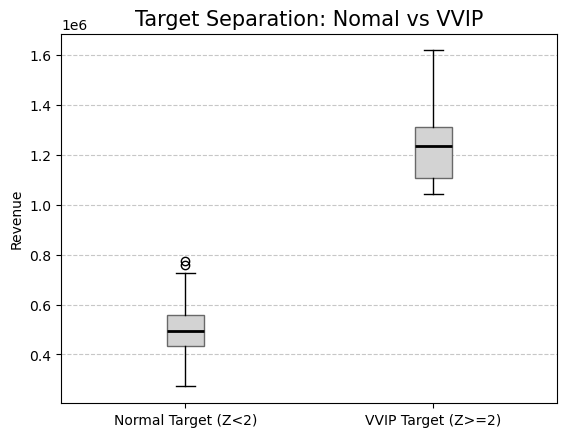

In [38]:
print("▶ 4. 분리 (일반 고객 vs VVIP 고객 투트랙 분석)")

# Z-Score 기준으로 그룹을 두 개로 쪼개기
normal_group = df_revenue[abs(df_revenue["Z-Score"]) < 2.0]
vvip_group = df_revenue[abs(df_revenue["Z-Score"]) >= 2.0]

print(f" [일반 타겟 그룹]{len(normal_group)}명 / 평균 결제일: {normal_group["일일 매출액"].mean():,.0f}원")
print(f" [VVIP 타겟 그룹]{len(vvip_group)}명 / 평균 결제일: {vvip_group["일일 매출액"].mean():,.0f}원")


# 일반 그룹과 VVIP 그룹의 결제액 데이터를 리스트로 묶어서 박스플롯으로 시각화
plt.boxplot(
    [normal_group["일일 매출액"], vvip_group["일일 매출액"]],
    vert = True,
    patch_artist = True,
    tick_labels = ["Normal Target (Z<2)","VVIP Target (Z>=2)"],
    boxprops = dict(facecolor = "lightgray", color = "dimgray"),
    medianprops = dict(color = "black", linewidth =2)
)


plt.title("Target Separation: Nomal vs VVIP", fontsize = 15)
plt.ylabel("Revenue")
plt.grid(axis="y", linestyle = "--", alpha = 0.7)
plt.show()